In [6]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_PATH = "/content/drive/MyDrive/EpiGuard_AI"
RAW_PATH = f"{BASE_PATH}/data/raw"
PROCESSED_PATH = f"{BASE_PATH}/data/processed"

os.makedirs(RAW_PATH, exist_ok=True)
os.makedirs(PROCESSED_PATH, exist_ok=True)

Mounted at /content/drive


Loading datasets...
All datasets loaded.
Exported: processed_covid.csv, latest_snapshot.csv


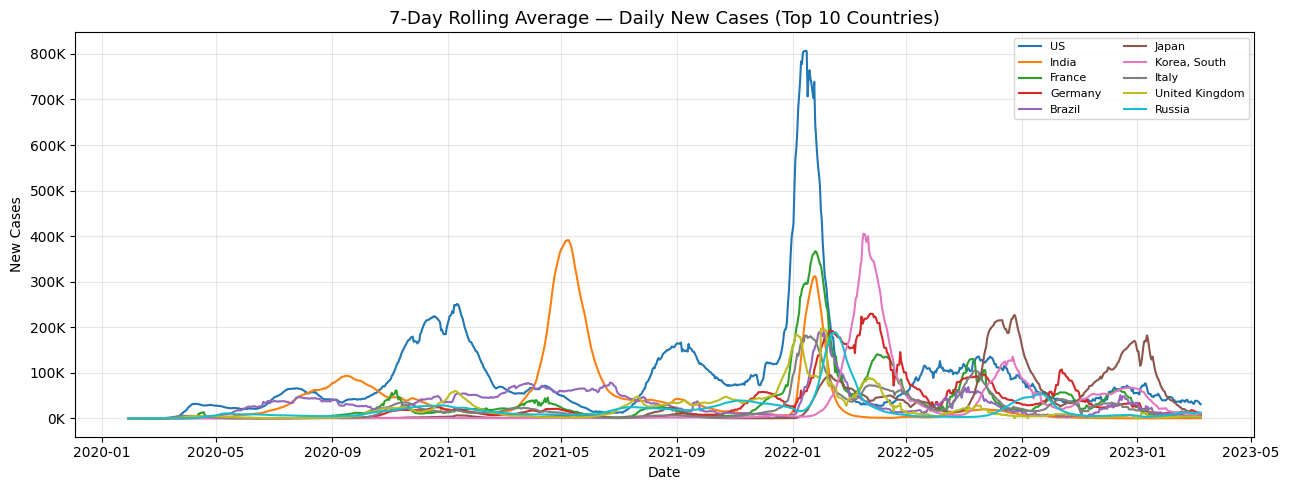

Saved: eda_rolling_avg.png


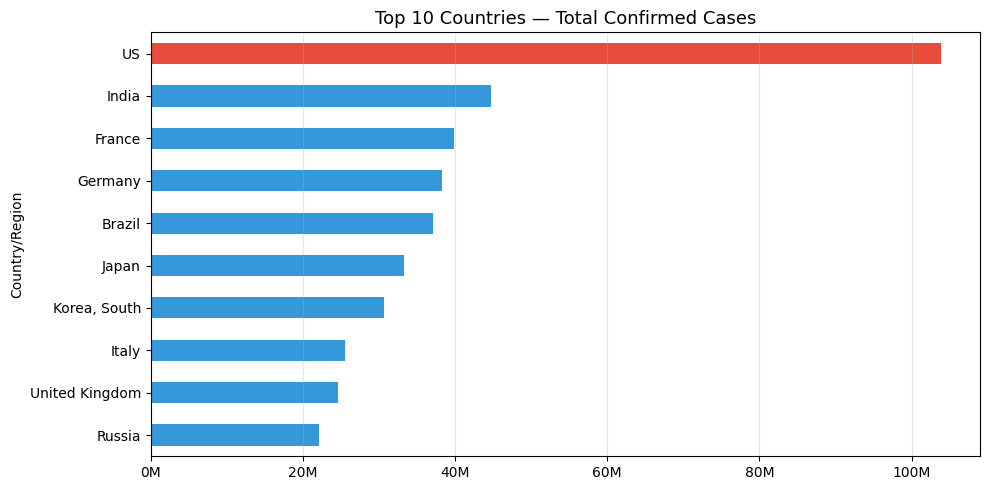

Saved: eda_total_cases.png


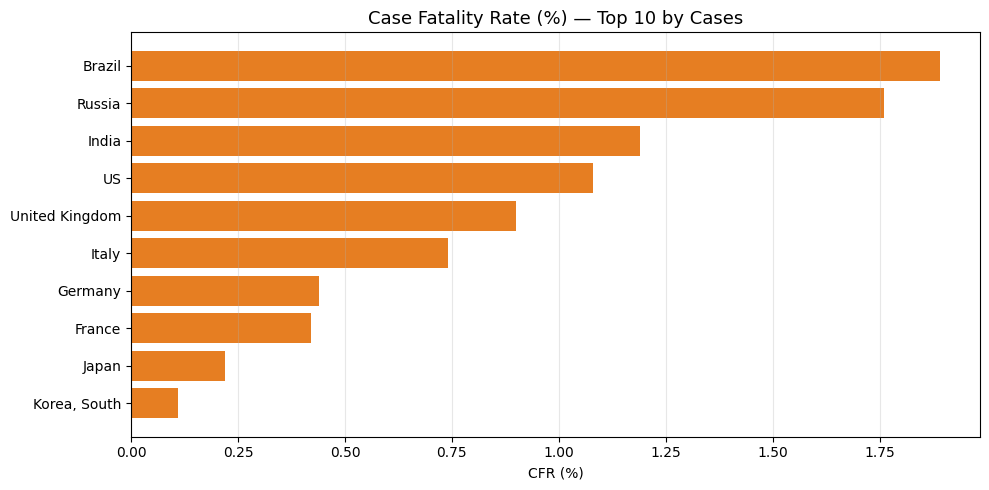

Saved: eda_cfr.png

✅ EDA complete. Files ready to download.
Total records: 229,743 | Countries: 201


In [9]:
# ============================================================
# EpiGuard AI — Notebook 1: EDA & Preprocessing
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── 1. LOAD DATA ─────────────────────────────────────────────
df_confirmed = pd.read_csv(f"{RAW_PATH}/time_series_covid19_confirmed_global.csv")
df_deaths = pd.read_csv(f"{RAW_PATH}/time_series_covid19_deaths_global.csv")
df_recovered = pd.read_csv(f"{RAW_PATH}/time_series_covid19_recovered_global.csv")
df_pop = pd.read_csv(f"{RAW_PATH}/population.csv")

print("Loading datasets...")
df_confirmed  = pd.read_csv(confirmed_url)
df_deaths     = pd.read_csv(deaths_url)
df_recovered  = pd.read_csv(recovered_url)
df_pop        = pd.read_csv(pop_url)
print("All datasets loaded.")

# ── 2. RESHAPE FUNCTION ──────────────────────────────────────
def reshape(df, col_name):
    df = df.drop(columns=['Province/State','Lat','Long'], errors='ignore')
    df = df.groupby('Country/Region').sum().reset_index()
    df = df.melt(id_vars='Country/Region', var_name='date', value_name=col_name)
    df['date'] = pd.to_datetime(df['date'])
    return df

df_c = reshape(df_confirmed, 'confirmed')
df_d = reshape(df_deaths,    'deaths')
df_r = reshape(df_recovered, 'recovered')

# ── 3. MERGE INTO MASTER ─────────────────────────────────────
df = df_c.merge(df_d, on=['Country/Region','date']) \
         .merge(df_r, on=['Country/Region','date'])

# ── 4. DAILY NEW CASES ───────────────────────────────────────
df = df.sort_values(['Country/Region','date'])
df['daily_confirmed'] = df.groupby('Country/Region')['confirmed'].diff().clip(lower=0)
df['daily_deaths']    = df.groupby('Country/Region')['deaths'].diff().clip(lower=0)
df['rolling_7']       = df.groupby('Country/Region')['daily_confirmed'].transform(lambda x: x.rolling(7).mean())
df['cfr']             = (df['deaths'] / df['confirmed'].replace(0, float('nan')) * 100).round(2)

# ── 5. MERGE POPULATION ──────────────────────────────────────
pop_latest = df_pop[df_pop['Year'] == df_pop['Year'].max()][['Country Name','Value']].copy()
pop_latest.columns = ['Country/Region','population']
# fix common name mismatches
name_map = {
    'United States': 'US',
    'Russian Federation': 'Russia',
    'Iran, Islamic Rep.': 'Iran',
    'Korea, Rep.': 'Korea, South',
    'Egypt, Arab Rep.': 'Egypt',
    'Venezuela, RB': 'Venezuela',
    'Syrian Arab Republic': 'Syria',
    'Yemen, Rep.': 'Yemen',
    'Congo, Dem. Rep.': 'Congo (Kinshasa)',
    'Congo, Rep.': 'Congo (Brazzaville)',
}
pop_latest['Country/Region'] = pop_latest['Country/Region'].replace(name_map)
df = df.merge(pop_latest, on='Country/Region', how='left')
df['cases_per_million'] = (df['confirmed'] / df['population'] * 1e6).round(2)

# ── 6. RISK SCORE ────────────────────────────────────────────
def risk_tier(val):
    if   val > 150000: return 'Critical'
    elif val >  50000: return 'High'
    elif val >  10000: return 'Medium'
    else:              return 'Low'

latest_per_country = df.groupby('Country/Region').last().reset_index()
latest_per_country['risk_tier'] = latest_per_country['cases_per_million'].apply(risk_tier)

# ── 7. EXPORT ────────────────────────────────────────────────
df.to_csv('processed_covid.csv', index=False)
latest_per_country.to_csv('latest_snapshot.csv', index=False)
print("Exported: processed_covid.csv, latest_snapshot.csv")

# ── 8. PLOTS ─────────────────────────────────────────────────
top10 = df.groupby('Country/Region')['confirmed'].max().nlargest(10).index
df_top = df[df['Country/Region'].isin(top10)]

# Plot 1 — 7-day rolling avg
fig, ax = plt.subplots(figsize=(13, 5))
for country in top10:
    d = df_top[df_top['Country/Region'] == country]
    ax.plot(d['date'], d['rolling_7'], label=country, linewidth=1.5)
ax.set_title('7-Day Rolling Average — Daily New Cases (Top 10 Countries)', fontsize=13)
ax.set_xlabel('Date'); ax.set_ylabel('New Cases')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('eda_rolling_avg.png', dpi=150)
plt.show()
print("Saved: eda_rolling_avg.png")

# Plot 2 — Total confirmed bar chart
fig, ax = plt.subplots(figsize=(10, 5))
totals = df.groupby('Country/Region')['confirmed'].max().nlargest(10).sort_values()
colors = ['#e74c3c' if c == totals.idxmax() else '#3498db' for c in totals.index]
totals.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Top 10 Countries — Total Confirmed Cases', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e6)}M'))
ax.grid(axis='x', alpha=0.3); plt.tight_layout()
plt.savefig('eda_total_cases.png', dpi=150)
plt.show()
print("Saved: eda_total_cases.png")

# Plot 3 — CFR top 10
fig, ax = plt.subplots(figsize=(10, 5))
cfr_data = latest_per_country.nlargest(10,'confirmed')[['Country/Region','cfr']].sort_values('cfr')
ax.barh(cfr_data['Country/Region'], cfr_data['cfr'], color='#e67e22')
ax.set_title('Case Fatality Rate (%) — Top 10 by Cases', fontsize=13)
ax.set_xlabel('CFR (%)'); ax.grid(axis='x', alpha=0.3); plt.tight_layout()
plt.savefig('eda_cfr.png', dpi=150)
plt.show()
print("Saved: eda_cfr.png")

print("\n✅ EDA complete. Files ready to download.")
print(f"Total records: {len(df):,} | Countries: {df['Country/Region'].nunique()}")

In [10]:
# ── 7. EXPORT ────────────────────────────────────────────────
df.to_csv(f"{PROCESSED_PATH}/processed_covid.csv", index=False)
latest_per_country.to_csv(f"{PROCESSED_PATH}/latest_snapshot.csv", index=False)

print("✅ Saved to Google Drive:")
print(PROCESSED_PATH)

✅ Saved to Google Drive:
/content/drive/MyDrive/EpiGuard_AI/data/processed


In [11]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# EpiGuard AI — Notebook 1: EDA & Preprocessing
# ============================================================

BASE_PATH = "/content/drive/MyDrive/EpiGuard_AI"
RAW_PATH = f"{BASE_PATH}/data/raw"
PROCESSED_PATH = f"{BASE_PATH}/data/processed"

os.makedirs(RAW_PATH, exist_ok=True)
os.makedirs(PROCESSED_PATH, exist_ok=True)

# ── 1. LOAD DATA ─────────────────────────────────────────────
print("📂 Loading datasets from Google Drive...")

df_confirmed = pd.read_csv(f"{RAW_PATH}/time_series_covid19_confirmed_global.csv")
df_deaths = pd.read_csv(f"{RAW_PATH}/time_series_covid19_deaths_global.csv")
df_recovered = pd.read_csv(f"{RAW_PATH}/time_series_covid19_recovered_global.csv")
df_pop = pd.read_csv(f"{RAW_PATH}/population.csv")

print("✅ All datasets loaded.")

# ── 2. RESHAPE FUNCTION ──────────────────────────────────────
def reshape(df, col_name):
    df = df.drop(columns=['Province/State', 'Lat', 'Long'], errors='ignore')
    df = df.groupby('Country/Region').sum().reset_index()
    df = df.melt(id_vars='Country/Region', var_name='date', value_name=col_name)
    df['date'] = pd.to_datetime(df['date'])
    return df

df_c = reshape(df_confirmed, 'confirmed')
df_d = reshape(df_deaths, 'deaths')
df_r = reshape(df_recovered, 'recovered')

# ── 3. MERGE INTO MASTER ─────────────────────────────────────
df = df_c.merge(df_d, on=['Country/Region', 'date']) \
         .merge(df_r, on=['Country/Region', 'date'])

# ── 4. DAILY FEATURES ────────────────────────────────────────
df = df.sort_values(['Country/Region', 'date'])
df['daily_confirmed'] = df.groupby('Country/Region')['confirmed'].diff().clip(lower=0)
df['daily_deaths'] = df.groupby('Country/Region')['deaths'].diff().clip(lower=0)
df['rolling_7'] = df.groupby('Country/Region')['daily_confirmed'].transform(
    lambda x: x.rolling(7).mean()
)
df['cfr'] = (
    df['deaths'] / df['confirmed'].replace(0, float('nan')) * 100
).round(2)

# ── 5. MERGE POPULATION ──────────────────────────────────────
pop_latest = df_pop[df_pop['Year'] == df_pop['Year'].max()][['Country Name', 'Value']].copy()
pop_latest.columns = ['Country/Region', 'population']

name_map = {
    'United States': 'US',
    'Russian Federation': 'Russia',
    'Iran, Islamic Rep.': 'Iran',
    'Korea, Rep.': 'Korea, South',
    'Egypt, Arab Rep.': 'Egypt',
    'Venezuela, RB': 'Venezuela',
    'Syrian Arab Republic': 'Syria',
    'Yemen, Rep.': 'Yemen',
    'Congo, Dem. Rep.': 'Congo (Kinshasa)',
    'Congo, Rep.': 'Congo (Brazzaville)',
}
pop_latest['Country/Region'] = pop_latest['Country/Region'].replace(name_map)

df = df.merge(pop_latest, on='Country/Region', how='left')
df['cases_per_million'] = (df['confirmed'] / df['population'] * 1e6).round(2)

# ── 6. RISK SCORE ────────────────────────────────────────────
def risk_tier(val):
    if val > 150000:
        return 'Critical'
    elif val > 50000:
        return 'High'
    elif val > 10000:
        return 'Medium'
    return 'Low'

latest_per_country = (
    df.sort_values('date')
      .groupby('Country/Region')
      .tail(1)
      .reset_index(drop=True)
)

latest_per_country['risk_tier'] = latest_per_country['cases_per_million'].apply(risk_tier)

# ── 7. EXPORT TO DRIVE ───────────────────────────────────────
df.to_csv(f"{PROCESSED_PATH}/processed_covid.csv", index=False)
latest_per_country.to_csv(f"{PROCESSED_PATH}/latest_snapshot.csv", index=False)

print("✅ Saved to Google Drive:")
print(PROCESSED_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Loading datasets from Google Drive...
✅ All datasets loaded.
✅ Saved to Google Drive:
/content/drive/MyDrive/EpiGuard_AI/data/processed
